## Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

### Load Data
`load_data` figures out the file format and, for delimited text, the separator, on its own — no assumptions are hardcoded here.

In [2]:
def load_data(path):
    """
    Load a tabular data file into a pandas DataFrame without assuming its
    format or, for delimited text, its separator. Tries readers roughly in
    order of what the extension suggests, then falls through the rest —
    including generic delimiter sniffing — until one works.
    """
    import pandas as pd
    from pathlib import Path

    ext = Path(path).suffix.lower()

    def read_delimited(p):
        # sep=None + engine="python" makes pandas sniff the actual delimiter
        # (comma, semicolon, tab, pipe, whitespace, ...) from the file itself.
        return pd.read_csv(p, sep=None, engine="python")

    candidates = {
        "excel": lambda p: pd.read_excel(p),
        "json": lambda p: pd.read_json(p),
        "parquet": lambda p: pd.read_parquet(p),
        "feather": lambda p: pd.read_feather(p),
        "delimited": read_delimited,
    }

    ext_hint = {
        ".xlsx": "excel", ".xls": "excel", ".xlsm": "excel",
        ".json": "json",
        ".parquet": "parquet",
        ".feather": "feather",
    }.get(ext, "delimited")

    order = [ext_hint] + [k for k in candidates if k != ext_hint]

    errors = {}
    for key in order:
        try:
            df = candidates[key](path)
            if key != ext_hint:
                print(f"Note: '{ext}' didn't load as expected; loaded successfully as {key} instead.")
            return df
        except Exception as e:
            errors[key] = e

    raise ValueError(
        f"Could not load {path!r} with any known reader. Tried: "
        + ", ".join(f"{k} ({e.__class__.__name__})" for k, e in errors.items())
    )


In [3]:
df = load_data('data/Penguin Species Prediction Dataset.csv')
df.shape

(1000, 7)

### Initial Inspection

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            1000 non-null   object 
 1   island             1000 non-null   object 
 2   culmen_length_mm   990 non-null    float64
 3   culmen_depth_mm    990 non-null    float64
 4   flipper_length_mm  990 non-null    float64
 5   body_mass_g        990 non-null    float64
 6   sex                990 non-null    object 
dtypes: float64(4), object(3)
memory usage: 54.8+ KB


In [5]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,41.1,18.4,195.0,3886.0,Female
1,Gentoo,Biscoe,50.0,15.4,217.0,4303.0,Male
2,Gentoo,Biscoe,50.0,15.1,220.0,4954.0,Female
3,Chinstrap,Dream,48.7,19.0,196.0,3739.0,Male
4,Adelie,Dream,39.0,17.8,187.0,3607.0,Male


### Descriptive Statistics — Numerical Features

In [6]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,990.000000,990.000000,990.000000,990.000000
mean,43.817778,17.335556,199.224242,4103.311111
std,5.309985,1.779057,13.171660,705.334794
min,32.400000,13.000000,175.000000,2830.000000
25%,39.000000,15.800000,189.000000,3586.000000
50%,43.800000,17.800000,195.000000,3882.000000
75%,48.300000,18.700000,212.000000,4587.000000
max,56.000000,21.400000,235.000000,6317.000000


### Descriptive Statistics — Categorical Features

In [7]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
if len(cat_cols) > 0:
    display(df[cat_cols].describe())
else:
    print('No categorical columns detected.')

,species,island,sex
count,1000,1000,990
unique,3,3,2
top,Adelie,Dream,Male
freq,461,527,528


### Missing Values

In [8]:
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100
missing_summary = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_summary

,missing_count,missing_pct
culmen_length_mm,10,1.0
culmen_depth_mm,10,1.0
flipper_length_mm,10,1.0
body_mass_g,10,1.0
sex,10,1.0


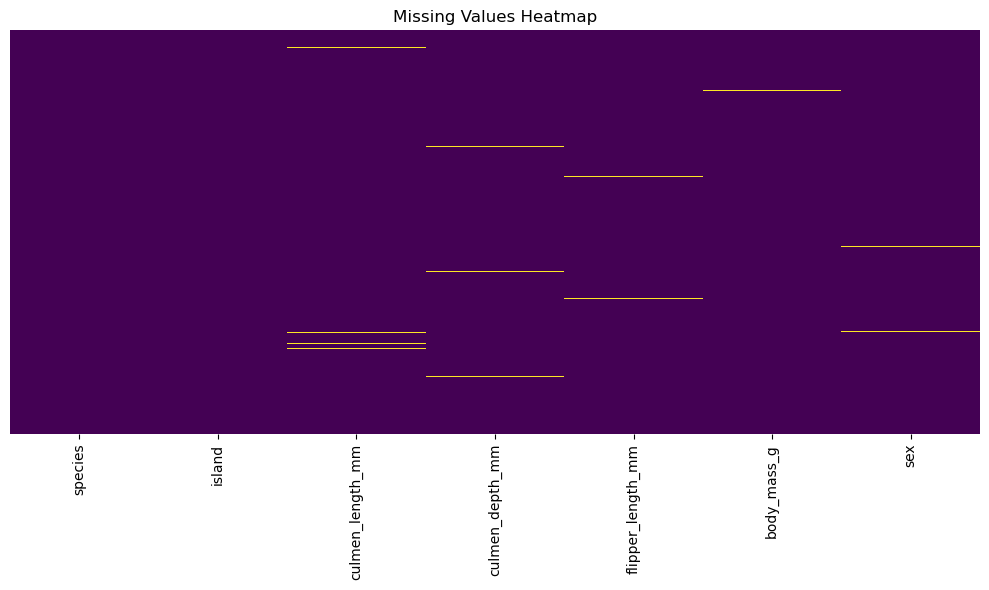

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

### Duplicate Rows

In [10]:
dup_count = df.duplicated().sum()
print(f'Number of duplicate rows: {dup_count}')
if dup_count > 0:
    display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()[0]))

Number of duplicate rows: 0
